# Showcase — NO₂ over China during the 2020 COVID lockdown (Sentinel-5P)

When China locked down in early 2020, road traffic and industry collapsed — and the drop was visible from orbit. **Sentinel-5P/TROPOMI** maps tropospheric nitrogen dioxide (NO₂), a marker of combustion. This notebook uses earthlens to pull TROPOMI NO₂ composites over eastern China for Feb–Mar **2019** vs the same window in **2020**, and maps the difference.

> Runs real Earth Engine requests; degrades gracefully without GEE credentials.

In [1]:
import os, tempfile, base64
import numpy as np, matplotlib.pyplot as plt
import matplotlib.animation as manim
from loguru import logger
from IPython.display import HTML
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens"); logger.disable("pyramids")

SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")


def grab(start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    out = tempfile.mkdtemp(prefix="gee_")
    el = EarthLens(
        data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={COLLECTION: list(bands)},
        lat_lim=[AOI[1], AOI[3]], lon_lim=[AOI[0], AOI[2]],
        path=out, scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
    )
    try:
        paths = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - notebook stays runnable without creds
        print("download skipped (needs GEE credentials):", exc); return None
    return str(paths[0]) if paths else None


def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")


def stretch(b, pct=(2, 98)):
    lo, hi = np.nanpercentile(b, pct[0]), np.nanpercentile(b, pct[1])
    return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)


def true_colour(arr):
    return np.dstack([stretch(arr[i]) for i in range(3)])


def gif_html(frames, titles, suptitle, cmap=None, figsize=(6, 6), fps=1.0):
    fig, ax = plt.subplots(figsize=figsize); fig.subplots_adjust(0, 0, 1, 0.93)
    def update(i):
        ax.clear(); ax.imshow(frames[i], cmap=cmap)
        ax.set_title(f"{suptitle}\n{titles[i]}", fontsize=11); ax.axis("off")
    anim = manim.FuncAnimation(fig, update, frames=len(frames), interval=int(1000 / fps))
    path = os.path.join(tempfile.mkdtemp(), "anim.gif")
    anim.save(path, writer=manim.PillowWriter(fps=fps)); plt.close(fig)
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return HTML(f'<img src="data:image/gif;base64,{b64}" alt="{suptitle}" style="max-width:560px"/>')

COLLECTION = "COPERNICUS/S5P/OFFL/L3_NO2"
AOI = [108.0, 28.0, 122.5, 41.0]  # eastern China (Beijing–Wuhan–Shanghai)
NO2 = "tropospheric_NO2_column_number_density"

## February–March, 2019 vs 2020

Mean TROPOMI NO₂ column over the same six-week window each year.

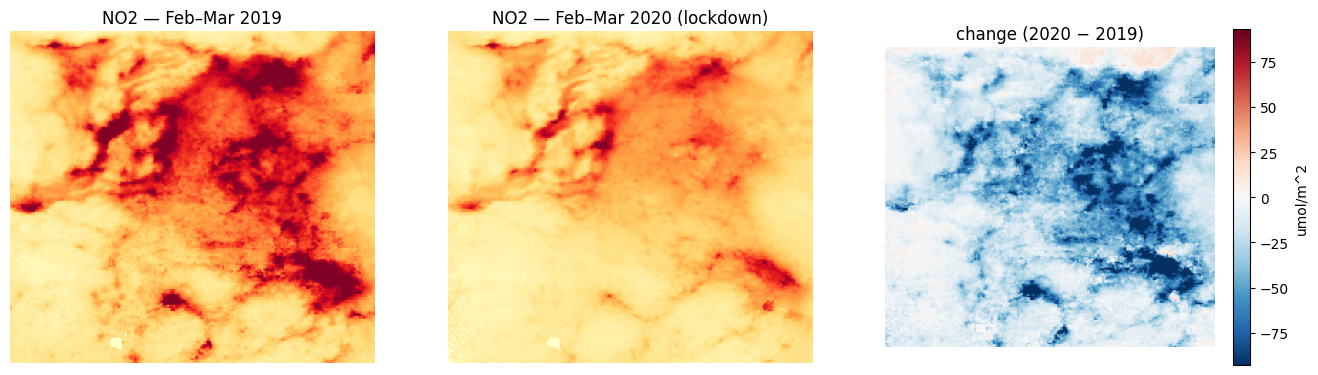

mean tropospheric NO2 fell 36% over eastern China (Feb–Mar 2020 vs 2019)


In [2]:
a2019 = grab("2019-02-01", "2019-03-15", [NO2], scale=7000, reducer="mean")
a2020 = grab("2020-02-01", "2020-03-15", [NO2], scale=7000, reducer="mean")
if a2019 and a2020:
    n19 = read(a2019); n20 = read(a2020)
    n19 = n19 if n19.ndim == 2 else n19[0]; n20 = n20 if n20.ndim == 2 else n20[0]
    scale_umol = 1e6  # mol/m^2 -> umol/m^2 for readable numbers
    vmax = float(np.nanpercentile(np.concatenate([n19.ravel(), n20.ravel()]), 98)) * scale_umol
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    ax[0].imshow(n19 * scale_umol, cmap="YlOrRd", vmin=0, vmax=vmax); ax[0].set_title("NO2 — Feb–Mar 2019")
    ax[1].imshow(n20 * scale_umol, cmap="YlOrRd", vmin=0, vmax=vmax); ax[1].set_title("NO2 — Feb–Mar 2020 (lockdown)")
    im = ax[2].imshow((n20 - n19) * scale_umol, cmap="RdBu_r", vmin=-vmax / 2, vmax=vmax / 2)
    ax[2].set_title("change (2020 − 2019)")
    for a in ax: a.axis("off")
    fig.colorbar(im, ax=ax[2], fraction=0.046, label="umol/m^2")
    plt.show()
    drop = (1 - np.nanmean(n20) / np.nanmean(n19)) * 100
    print(f"mean tropospheric NO2 fell {drop:.0f}% over eastern China (Feb–Mar 2020 vs 2019)")
else:
    print("no scenes — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")